# Principal Component Analysis

            ## 1. Learning objectives

            - Connect covariance with directions of variation
- Implement PCA using eigenvectors
- Choose a component count with explained variance

            ## 2. Prerequisites

            Basic NumPy arrays, means, and two-dimensional scatter plots.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Compress correlated features into fewer orthogonal coordinates while retaining as much variance as possible.

            ## 4. Real-world use cases

            - Exploratory customer grouping
- Representation learning
- Quality-control pattern discovery

            ## 5. Core intuition in simple language

            Rotate the coordinate system so the first axis follows the widest spread and later axes follow remaining spread.

## 6. Mathematical foundation

            $$\mathbf{C}\mathbf{v}=\lambda\mathbf{v}.$$

            **Every symbol:**

            - $\mathbf{C}$ is the covariance matrix.
- $\mathbf{v}$ is an eigenvector and principal direction.
- $\lambda$ is its eigenvalue and captured variance.

            **Why the equation is needed:** Covariance eigenvectors identify directions whose projected variance is measured by the eigenvalue.

            **Small numerical example:** For covariance diag(9,1), the first axis explains 9/(9+1)=90% of variance.

            **Connection to Python:** np.linalg.eigh(covariance) returns eigenvalues and directions.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Represent each observation as a feature vector
2. Scale features when units differ
3. Fit the structure-discovery rule
4. Evaluate stability and usefulness
5. Inspect the result visually and with domain knowledge

## 9. Implementation from scratch

We implement the smallest useful version in NumPy so every update remains visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def pca_scratch(features, components=2):
    mean = features.mean(axis=0)
    centered = features - mean
    covariance = centered.T @ centered / (len(features) - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    directions = eigenvectors[:, order[:components]]
    transformed = centered @ directions
    explained_ratio = eigenvalues[order[:components]] / eigenvalues.sum()
    return transformed, directions, explained_ratio

tiny = np.array([[1., 1.], [2., 2.], [3., 3.]])
print("Tiny first-component scores:", pca_scratch(tiny, 1)[0].round(3).ravel())

Tiny first-component scores: [-1.414  0.     1.414]


## 10. Implementation using a standard library

Scikit-learn adds input validation, efficient routines, and a consistent estimator API.

## 11. Dataset loading and exploration

The lesson uses a small built-in or synthetic dataset with a fixed seed and no network dependency.

## 12. Data preprocessing

Features are standardized when distance or covariance would otherwise be dominated by measurement units.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Input/projected shapes: (1797, 64) (1797, 2)
Explained variance: [0.12  0.096] component agreement: [1. 1.]


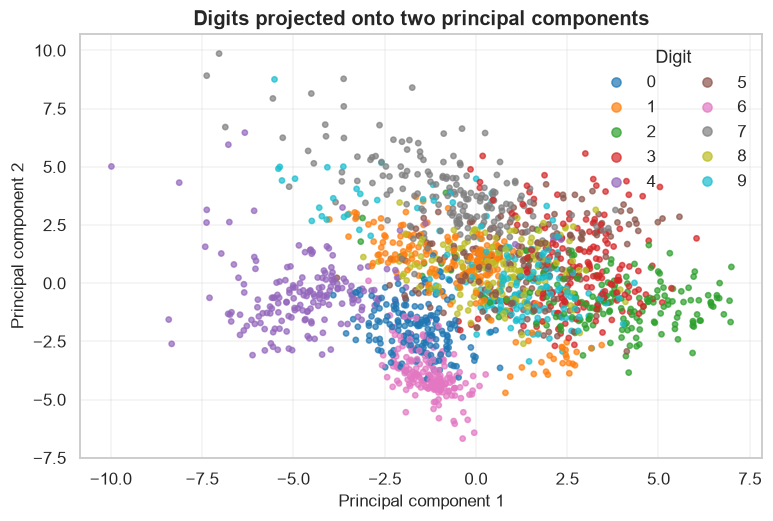

In [3]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
scratch_projection, directions, scratch_ratio = pca_scratch(X, 2)
model = PCA(n_components=2).fit(X)
library_projection = model.transform(X)
correlations = [abs(np.corrcoef(scratch_projection[:, i], library_projection[:, i])[0, 1]) for i in range(2)]
print("Input/projected shapes:", X.shape, library_projection.shape)
print("Explained variance:", model.explained_variance_ratio_.round(3), "component agreement:", np.round(correlations, 3))

figure, axis = plt.subplots()
scatter = axis.scatter(library_projection[:, 0], library_projection[:, 1], c=y, cmap="tab10", s=12, alpha=.7)
axis.set(title="Digits projected onto two principal components", xlabel="Principal component 1", ylabel="Principal component 2")
axis.legend(*scatter.legend_elements(), title="Digit", ncol=2, loc="best")
plt.show()

**How to interpret the result:** Nearby projected points share dominant pixel patterns, but overlap warns that two dimensions cannot preserve all information.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

More components preserve more information but reduce less dimensionality.

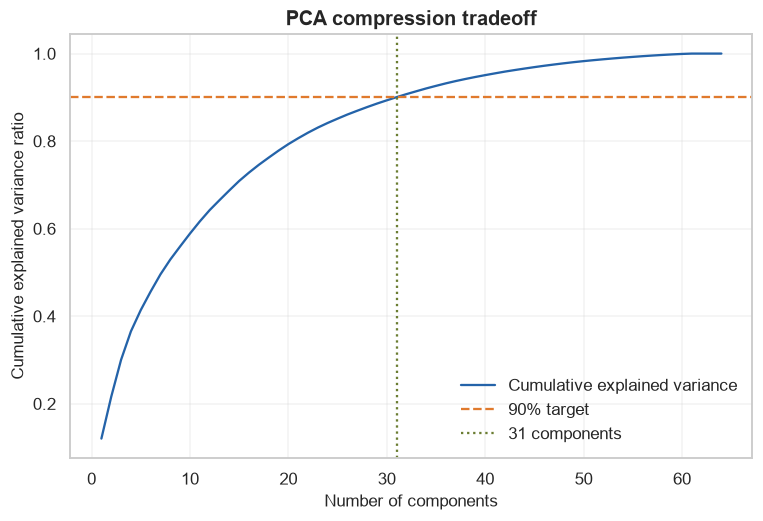

In [4]:
full_pca = PCA().fit(X)
cumulative = np.cumsum(full_pca.explained_variance_ratio_)
components_90 = int(np.searchsorted(cumulative, .90) + 1)
figure, axis = plt.subplots()
axis.plot(np.arange(1, len(cumulative) + 1), cumulative, color=COURSE_COLORS["blue"], label="Cumulative explained variance")
axis.axhline(.90, color=COURSE_COLORS["orange"], linestyle="--", label="90% target")
axis.axvline(components_90, color=COURSE_COLORS["olive"], linestyle=":", label=f"{components_90} components")
axis.set(title="PCA compression tradeoff", xlabel="Number of components", ylabel="Cumulative explained variance ratio")
axis.legend()
plt.show()

## 18. Common mistakes

            - Treating cluster identifiers as ordered numbers
- Skipping scaling for distance-based methods
- Assuming an attractive grouping is automatically useful

            ## 19. Advantages and disadvantages

            **Advantages**

            - Does not require labels
- Can expose previously unknown structure

            **Disadvantages**

            - Evaluation is indirect
- Results can be sensitive to representation and hyperparameters

            ## 20. When to use and when not to use the algorithm

            **Use it when:** exploration, compression, or structure discovery is the goal and trustworthy labels are unavailable.

            **Do not use it when:** a supervised target directly represents the decision or the learned grouping has no domain interpretation.

## 21. Exercises

1. **Conceptual:** Why can cluster labels 0 and 1 not be interpreted as low and high?
2. **Mathematical/hand calculation:** Compute the Euclidean distance between (0, 0) and (3, 4).
3. **Coding/experimentation:** Change the random seed and check whether the structure is stable.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Cluster IDs are arbitrary names; permuting them does not change the grouping.
2. $\sqrt{3^2+4^2}=5$.
3. Rerun with several seeds and compare scores plus assignments; instability is evidence that conclusions need caution.

</details>

## 23. Summary and key takeaways

            - Unsupervised methods learn from features without fitting to labels
- Scaling and representation strongly affect results
- Metrics, visualization, stability, and domain usefulness must be considered together

            ## 24. Further reading

            - [scikit-learn PCA documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)